# N11 — Memória Reflexiva

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook trata da **memória reflexiva**, a memória de longo prazo de um agente composta de duas operações: a recuperação dos registros mais parecidos com a pergunta atual e a gravação de uma lição quando uma resposta é reprovada. As seções seguintes constroem a busca por similaridade sobre o store e o ciclo de avaliação e reflexão que produz as lições.

A seção 4 mede o efeito da recuperação em dados de um trabalho publicado: o modelo phi-2 respondendo questões de ciências com e sem exemplos recuperados por similaridade. As seções 5 e 6 montam em LangGraph um tutor que recupera lições, responde, é avaliado contra um critério do professor e grava uma lição quando a resposta é reprovada.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, `dataclass`, anotações de tipo e f-strings;
- construção de grafos com `StateGraph`, `add_node`, `add_edge` e `add_conditional_edges`, com estado declarado em `TypedDict`;
- store do LangGraph: `put` e `search` sobre namespaces, `SqliteStore`, e leitura de `runtime.store` e `runtime.context` dentro de um nó;
- saída estruturada com `with_structured_output` e esquemas Pydantic (`BaseModel` e `Field`);
- vetores e produto escalar em `numpy`.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Verificar que a listagem de um namespace devolve os registros sem relação com a pergunta.
2. Distinguir os dois componentes da memória reflexiva: recuperação seletiva e reflexão.
3. Implementar, com `numpy`, a representação TF-IDF de textos e a busca dos *k* registros mais parecidos com uma consulta pela similaridade de cosseno.
4. Medir, em uma amostra do ARC Challenge, em quantas questões a recuperação de exemplos melhora e em quantas piora a resposta do modelo phi-2.
5. Construir em LangGraph um agente que recupera lições, responde, é avaliado contra um critério e grava uma lição quando a resposta é reprovada.
6. Identificar os limites da memória reflexiva: lições gravadas a partir de avaliações erradas, recuperação por vocabulário e crescimento do namespace.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Listagem de um namespace.
2. Memória reflexiva.
3. Busca por similaridade.
4. Estudo de caso: ARC Challenge.
5. Agente reflexivo em LangGraph.
6. Lições acumuladas entre execuções.
7. Limites da memória reflexiva.
8. Exercícios de fixação.
9. Resumo da aula.
10. Referências.

## 0.4 Contexto usado nos exemplos

O notebook usa dois cenários. O primeiro é o tutor de um curso de agentes com LLMs, organizado em módulos: os temas de estado e reducers ficam no módulo `A4`, e os de checkpointer e store no módulo `A6`. O aluno Renan tem oito episódios gravados no store, um por sessão anterior, e faz perguntas ao tutor. Cada pergunta chega acompanhada de um critério escrito pelo professor, com um ponto de conteúdo e o módulo do tema. O tutor não recebe o critério, e o avaliador recebe.

O segundo cenário é um recorte de 22 questões de ciências do dataset **ARC Challenge**, respondidas pelo modelo phi-2 com e sem exemplos recuperados por similaridade. O recorte traz as respostas já gravadas pelos autores do trabalho e está escrito na célula da seção 4.1. O notebook não executa o phi-2 e não lê arquivo externo; as chamadas de modelo das seções 5 e 6 usam o provedor da seção 0.6.

---

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. Nenhum modelo é baixado na máquina. A seção 0.6 registra também a configuração do Gemini (`gemini-3.5-flash-lite`), para o caso de a execução ser feita pela API do Google. O tutor recebe uma lista de mensagens e devolve texto; o avaliador e o nó de reflexão usam saída estruturada.

As bibliotecas são `langchain` e `langgraph` (mensagens, grafo e `Runtime`), `langgraph-checkpoint-sqlite` (`SqliteStore`, gravado em arquivo SQLite), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores), `pydantic` (esquemas da saída estruturada), `numpy` (vetores da busca por similaridade) e `python-dotenv` (leitura das chaves). A célula de imports carrega os dois clientes, então os dois pacotes precisam estar instalados; a constante `PROVEDOR` da seção 0.6 seleciona qual deles é instanciado.

O acesso ao modelo hospedado pelo Ollama exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Para o Gemini, a chave é gerada em [aistudio.google.com/apikey](https://aistudio.google.com/apikey) e guardada na variável `GOOGLE_API_KEY`. Há três formas de definir as variáveis. Em uma máquina local, escreva as linhas `OLLAMA_API_KEY=...` e `GOOGLE_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-las. A segunda forma é exportar as variáveis no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langchain langgraph langgraph-checkpoint-sqlite langchain-ollama langchain-google-genai pydantic numpy python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import json
import os
import re
import sqlite3
import uuid

from dataclasses import dataclass
from pathlib import Path
from typing import Annotated, Literal, TypedDict

import numpy as np

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.runtime import Runtime
from langgraph.store.base import BaseStore
from langgraph.store.sqlite import SqliteStore

from IPython.display import Image, display

Glossário dos imports:

- `json`: leitura da amostra do ARC Challenge, escrita como texto JSON na seção 4.1;
- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `re`: separação de um texto em palavras na seção 3.1;
- `sqlite3` e `Path`: abertura da conexão com o arquivo SQLite e remoção do arquivo de uma execução anterior;
- `uuid`: geração de uma chave distinta para cada episódio e cada lição gravados no store;
- `dataclass`: declaração do esquema de contexto da seção 5.1;
- `Annotated`, `Literal` e `TypedDict`: associação do reducer, tipo de retorno da função de roteamento e declaração dos campos do estado;
- `numpy`: vetores TF-IDF e similaridade de cosseno;
- `BaseModel` e `Field`: esquemas Pydantic da avaliação e da lição;
- `AnyMessage`, `HumanMessage` e `SystemMessage`: tipo comum às mensagens, a pergunta do aluno e a instrução fixa de cada chamada;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `StateGraph`, `START` e `END`: construtor do grafo e os nós virtuais de entrada e saída;
- `add_messages`: reducer que acrescenta as mensagens novas à lista do estado;
- `CompiledStateGraph`, `Image` e `display`: tipo do grafo compilado e exibição do desenho dele;
- `Runtime`: objeto entregue ao nó com o contexto da execução e o store compilado com o grafo;
- `BaseStore` e `SqliteStore`: interface comum aos stores e a implementação que grava em arquivo SQLite.

A função auxiliar abaixo exibe o desenho de um grafo compilado.

In [4]:
def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e as seções seguintes chamam o objeto `modelo` devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem nos pontos da tabela abaixo, e `criar_modelo` concentra os que afetam a construção do cliente:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature`, de 0 a 1 | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning`, ligado ou desligado | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Campo `content` da resposta | uma string | uma lista de blocos |

A última linha define como o texto da resposta é lido: as células usam o atributo `.text` da mensagem, que devolve uma string nos dois provedores. O limite de tokens cobre o raciocínio e a resposta juntos, inclusive com `reasoning=False` no Ollama, e o valor 1500 de `LIMITE_RESPOSTA` cobre as respostas de quatro frases pedidas pela instrução do tutor.

As saídas gravadas neste arquivo vêm do Ollama. As células também foram executadas pelo `gemini-3.5-flash-lite`, e as leituras de execução indicam onde as duas execuções diferem. Para executar pelo Gemini, defina `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`.

In [5]:
load_dotenv()

PROVEDOR = "ollama"  # troque para "gemini" depois de definir GOOGLE_API_KEY

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 1500  # tokens gerados por chamada, raciocínio incluído


def criar_modelo() -> ChatOllama | ChatGoogleGenerativeAI:
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if PROVEDOR == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if PROVEDOR == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        # A família Gemini 3.x fixa a amostragem, e temperature não é aceito.
        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {PROVEDOR}. Use 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

ollama | ChatOllama


### 0.6.1 Saída estruturada nos dois provedores

O avaliador e o nó de reflexão da seção 5 recebem a resposta do modelo em campos de um esquema Pydantic. Dois pontos da chamada `with_structured_output` dependem do provedor e ficam concentrados nas duas funções abaixo.

O primeiro é o argumento `method`. O valor padrão do `ChatOllama` pede o esquema JSON diretamente ao modelo, e o `gpt-oss:120b` responde com prosa em vez do objeto, o que termina em erro de parsing. Com `method="function_calling"`, o esquema é declarado como ferramenta e o modelo preenche os argumentos dela, forma que os dois provedores aceitam.

O segundo é o retorno vazio. O parser devolve `None` quando a resposta não traz a chamada com os campos preenchidos, e o acesso ao atributo seguinte quebra com `AttributeError`. `invocar_estruturado` repete o pedido quando isso acontece.

In [6]:
def criar_estruturado(esquema: type[BaseModel]):
    """Liga um esquema Pydantic ao modelo pelo método que os dois provedores aceitam."""
    return modelo.with_structured_output(esquema, method="function_calling")


def invocar_estruturado(estruturado, mensagens: list[AnyMessage], tentativas: int = 3):
    """Repete o pedido enquanto o parser devolver None, e levanta erro ao esgotar as tentativas."""
    for _ in range(tentativas):
        resultado = estruturado.invoke(mensagens)

        if resultado is not None:
            return resultado

    raise RuntimeError(f"O modelo não preencheu o esquema em {tentativas} tentativas.")

---

# 1. Listagem de um namespace

O store grava registros em namespaces, e `store.search(namespace)` devolve os registros de um namespace ordenados pela data de atualização. A ordem não depende do texto de nenhuma pergunta. Um agente que monta o prompt a partir dessa listagem envia ao modelo todos os registros devolvidos, relacionados ou não com a pergunta em curso.

```text
pergunta do aluno
      ↓
store.search(("episodios", "renan"))   → até limit episódios (10 por padrão), do mais recente ao mais antigo
      ↓
prompt = instrução + episódios devolvidos + pergunta
```

A célula abaixo abre o store em um arquivo SQLite. O arquivo de uma execução anterior é apagado antes da abertura; sem isso, cada execução do notebook acrescentaria outra cópia dos episódios e das lições, e as saídas das seções seguintes mudariam. O `SqliteStore` ativa o modo WAL do SQLite, que mantém ao lado do banco os arquivos `-wal` e `-shm`, e a função `apagar_banco` remove os três.

**Atenção:** o `SqliteStore` abre e fecha as próprias transações. A conexão é aberta com `isolation_level=None`, que desliga a transação implícita do módulo `sqlite3`; sem isso, a primeira escrita termina em `OperationalError: cannot start a transaction within a transaction`. O argumento `check_same_thread=False` permite que os nós do grafo, executados em outras threads do sistema operacional, usem a mesma conexão.

In [7]:
def apagar_banco(arquivo: Path) -> None:
    """Remove o banco SQLite e os arquivos -wal e -shm do modo WAL."""
    for sufixo in ["", "-wal", "-shm"]:
        Path(f"{arquivo}{sufixo}").unlink(missing_ok=True)


ARQUIVO_STORE = Path("memoria_reflexiva.db")
apagar_banco(ARQUIVO_STORE)

conexao_store = sqlite3.connect(
    ARQUIVO_STORE,
    check_same_thread=False,
    isolation_level=None,  # o SqliteStore abre e fecha as próprias transações
)
store = SqliteStore(conexao_store)
store.setup()

print(type(store).__name__, "|", ARQUIVO_STORE)

SqliteStore | memoria_reflexiva.db


Os oito episódios de Renan são gravados como uma coleção, um documento por chave `uuid4`, no namespace `("episodios", "renan")`.

In [8]:
episodios_renan = [
    "Perguntou sobre reducers e sobre como funciona o add_messages.",
    "Pediu ajuda para montar um roteador de intenção com LLM.",
    "Quis saber a diferença entre StateGraph e create_agent.",
    "Perguntou como funciona bind_tools e ToolMessage.",
    "Teve dúvida sobre por que usar TypedDict em vez de dict comum.",
    "Perguntou sobre ciclos e critério de parada em grafos.",
    "Quis entender a diferença entre checkpointer e store.",
    "Perguntou como funciona o RunnableConfig e o thread_id.",
]

for resumo in episodios_renan:
    store.put(("episodios", "renan"), str(uuid.uuid4()), {"resumo": resumo})

print(f"{len(episodios_renan)} episódios gravados para Renan.")

8 episódios gravados para Renan.


Renan pergunta agora como o `thread_id` separa as conversas no checkpointer. A listagem do namespace devolve:

In [9]:
pergunta_renan = "Como o thread_id separa as conversas no checkpointer?"

for item in store.search(("episodios", "renan")):
    print("-", item.value["resumo"])

- Perguntou sobre reducers e sobre como funciona o add_messages.
- Pediu ajuda para montar um roteador de intenção com LLM.
- Quis saber a diferença entre StateGraph e create_agent.
- Perguntou como funciona bind_tools e ToolMessage.
- Teve dúvida sobre por que usar TypedDict em vez de dict comum.
- Perguntou sobre ciclos e critério de parada em grafos.
- Quis entender a diferença entre checkpointer e store.
- Perguntou como funciona o RunnableConfig e o thread_id.


## 1.1 Discussão

A listagem devolve os oito episódios. Dois deles tratam do assunto da pergunta: o do `RunnableConfig` e do `thread_id`, e o da diferença entre checkpointer e store. Os outros seis tratam de reducers, roteadores, `create_agent`, `bind_tools`, `TypedDict` e ciclos. Como os oito foram gravados no mesmo segundo, a ordem é a de inserção, e o episódio do `thread_id` aparece por último.

Um prompt montado com essa listagem tem três propriedades. O número de tokens de memória cresce com o total de episódios, inclusive os sem relação com a pergunta. O `search` devolve no máximo `limit` itens, 10 por padrão, então a partir do décimo primeiro episódio os mais antigos deixam de ser lidos, relacionados ou não. E o modelo recebe os seis episódios sem relação junto com os dois relacionados, sem marca que os distinga.

---

# 2. Memória reflexiva

A memória reflexiva acrescenta ao store duas operações:

```text
(a) recuperação seletiva → antes de responder, ler só os registros mais parecidos com a pergunta
(b) reflexão             → depois de uma resposta reprovada, gravar uma lição para as perguntas seguintes
```

**(a) Recuperação seletiva.** Cada registro do namespace recebe uma nota de similaridade com a pergunta atual, e só os *k* registros de maior nota entram no prompt. A nota é calculada sobre vetores que representam os textos, e a seção 3 constrói uma representação e uma medida de similaridade com `numpy`.

**(b) Reflexão.** Uma resposta do agente passa por um avaliador. Quando ela é reprovada, uma chamada ao modelo recebe a pergunta, a resposta e a crítica do avaliador e escreve uma **lição**, uma instrução curta para respostas futuras sobre o mesmo tema. A lição é gravada no store e fica disponível para a operação (a) nas execuções seguintes. O arranjo segue o do Reflexion (Shinn et al., 2023), em que um agente guarda reflexões verbais sobre tentativas reprovadas e as recebe no prompt das tentativas seguintes.

As duas operações se compõem em um ciclo. A recuperação lê lições que a reflexão gravou, e a reflexão só grava depois que uma resposta, montada com as lições recuperadas, é reprovada.

---

# 3. Busca por similaridade

A busca desta seção compara textos pelo vocabulário. Cada texto vira um vetor com uma posição por palavra, e dois textos são parecidos quando os vetores apontam para direções próximas.

```text
consulta + textos do namespace
      ↓
gerar_embeddings  → um vetor TF-IDF por texto
      ↓
similaridade_cosseno(vetor da consulta, vetor de cada texto)
      ↓
ordenar pela similaridade e ficar com os k primeiros
```

## 3.1 Representação TF-IDF

Um **embedding** é um vetor de números que representa um texto. A representação **TF-IDF** atribui a cada palavra do vocabulário uma posição do vetor, com o valor igual ao produto de dois fatores:

- TF (*term frequency*): o número de ocorrências da palavra no texto;
- IDF (*inverse document frequency*): `log((1 + n) / (1 + df)) + 1`, em que `n` é o número de textos e `df` o número de textos que contêm a palavra. Uma palavra presente em todos os textos recebe o menor peso.

Palavras como `o`, `que`, `em` e `como` aparecem em textos de qualquer assunto. A função `tokenizar` as remove antes da contagem, por uma lista fixa, `PALAVRAS_VAZIAS`; sem a remoção, duas frases sobre assuntos diferentes recebem similaridade acima de zero por compartilharem essas palavras.

In [10]:
PALAVRAS_VAZIAS = {
    "a", "o", "as", "os", "e", "é", "de", "do", "da", "dos", "das", "em", "no", "na",
    "nos", "nas", "um", "uma", "que", "por", "para", "com", "como", "sobre", "se",
    "entre", "ao", "qual", "quais", "eu", "meu", "minha",
}


def tokenizar(texto: str) -> list[str]:
    """Separa o texto em palavras minúsculas e remove as palavras vazias."""
    palavras = re.findall(r"\w+", texto.lower())

    return [palavra for palavra in palavras if palavra not in PALAVRAS_VAZIAS]


def gerar_embeddings(textos: list[str]) -> np.ndarray:
    """Devolve uma matriz com um vetor TF-IDF por texto, sobre o vocabulário dos próprios textos."""
    palavras_por_texto = [tokenizar(texto) for texto in textos]
    vocabulario = sorted({palavra for palavras in palavras_por_texto for palavra in palavras})
    posicao = {palavra: indice for indice, palavra in enumerate(vocabulario)}

    tf = np.zeros((len(textos), len(vocabulario)))
    for linha, palavras in enumerate(palavras_por_texto):
        for palavra in palavras:
            tf[linha, posicao[palavra]] += 1

    df = (tf > 0).sum(axis=0)
    idf = np.log((1 + len(textos)) / (1 + df)) + 1

    return tf * idf

## 3.2 Similaridade de cosseno

A **similaridade de cosseno** é o cosseno do ângulo entre dois vetores. Com vetores TF-IDF, que não têm componentes negativas, o valor vai de 0, quando os textos não têm palavra em comum, a 1, quando as proporções entre as palavras são as mesmas.

```text
similaridade(a, b) = (a · b) / (||a|| * ||b||)
```

Um texto composto só de palavras vazias gera o vetor nulo, cuja norma é zero. A função devolve 0 nesse caso, em vez de dividir por zero.

In [11]:
def similaridade_cosseno(vetor_a: np.ndarray, vetor_b: np.ndarray) -> float:
    """Cosseno do ângulo entre dois vetores, ou 0 quando um deles é nulo."""
    norma_a = np.linalg.norm(vetor_a)
    norma_b = np.linalg.norm(vetor_b)

    if norma_a == 0 or norma_b == 0:
        return 0.0

    return float(np.dot(vetor_a, vetor_b) / (norma_a * norma_b))

## 3.3 Recuperação dos *k* registros mais parecidos

`buscar_relevantes` junta as duas funções. Ela lê o namespace, gera os vetores da consulta e dos textos de uma vez, sobre o mesmo vocabulário, e ordena os registros pela similaridade com a consulta. Os pesos IDF são recalculados a cada chamada, sobre o conjunto formado pela consulta e pelos textos lidos. A leitura usa `limit=100`, porque o `limit` padrão de `search` é 10 e cortaria o namespace antes da ordenação por similaridade.

In [12]:
def buscar_relevantes(
    store: BaseStore,
    namespace: tuple[str, ...],
    consulta: str,
    campo_texto: str,
    k: int = 3,
) -> list[dict]:
    """Devolve os k itens do namespace mais parecidos com a consulta, com a similaridade de cada um."""
    itens = store.search(namespace, limit=100)
    if not itens:
        return []

    textos = [item.value[campo_texto] for item in itens]
    matriz = gerar_embeddings([consulta, *textos])

    vetor_consulta = matriz[0]
    pontuados = [
        (similaridade_cosseno(vetor_consulta, vetor_item), item)
        for vetor_item, item in zip(matriz[1:], itens)
    ]
    pontuados.sort(key=lambda par: par[0], reverse=True)

    return [
        {"similaridade": similaridade, "valor": item.value}
        for similaridade, item in pontuados[:k]
    ]

A pergunta de Renan da seção 1, agora pela busca:

In [13]:
resultados = buscar_relevantes(
    store,
    ("episodios", "renan"),
    consulta=pergunta_renan,
    campo_texto="resumo",
    k=3,
)

for resultado in resultados:
    print(f"[{resultado['similaridade']:.2f}] {resultado['valor']['resumo']}")

[0.24] Perguntou como funciona o RunnableConfig e o thread_id.
[0.19] Quis entender a diferença entre checkpointer e store.
[0.00] Perguntou sobre reducers e sobre como funciona o add_messages.


## 3.4 Leitura da execução

1. Depois da remoção das palavras vazias, a pergunta tem as palavras `thread_id`, `separa`, `conversas` e `checkpointer`.
2. O episódio do `RunnableConfig` contém `thread_id`, e o da diferença entre checkpointer e store contém `checkpointer`. Os dois ocupam as duas primeiras posições, com similaridade acima de zero.
3. O terceiro item tem similaridade 0,00. Nenhum dos seis episódios restantes compartilha palavra com a pergunta, e a função devolve *k* itens mesmo quando os últimos têm nota zero.

## 3.5 Limite da comparação por vocabulário

A mesma dúvida, escrita com outras palavras, não compartilha nenhuma palavra com os episódios:

In [14]:
resultados = buscar_relevantes(
    store,
    ("episodios", "renan"),
    consulta="Como o grafo lembra o que o aluno disse antes?",
    campo_texto="resumo",
    k=3,
)

for resultado in resultados:
    print(f"[{resultado['similaridade']:.2f}] {resultado['valor']['resumo']}")

[0.00] Perguntou sobre reducers e sobre como funciona o add_messages.
[0.00] Pediu ajuda para montar um roteador de intenção com LLM.
[0.00] Quis saber a diferença entre StateGraph e create_agent.


## 3.6 Discussão

Os três itens devolvidos têm similaridade 0,00, e a ordem entre eles é a da leitura do namespace. A pergunta trata do mesmo assunto da seção 3.3, e a TF-IDF compara palavras: `grafo`, `lembra`, `aluno`, `disse` e `antes` não aparecem em nenhum episódio. A representação também não relaciona sinônimos nem formas flexionadas. O episódio sobre ciclos contém `grafos`, que ocupa uma posição do vetor diferente da de `grafo`.

Os embeddings calculados por um modelo de linguagem posicionam textos de mesmo assunto em direções próximas, mesmo sem palavras em comum. A recuperação continua a mesma com eles: gerar um vetor por texto, calcular a similaridade com a consulta e ficar com os *k* primeiros. O store do LangGraph implementa esse arranjo: construído com `index={"embed": <função de embeddings>, "dims": <dimensão>}`, ele calcula o vetor de cada item no `put`, e `store.search(namespace, query=...)` devolve os itens ordenados pela similaridade com a consulta.

---

# 4. Estudo de caso: ARC Challenge

Esta seção mede a operação (a) da seção 2 em dados de um trabalho publicado. O modelo phi-2 respondeu questões de múltipla escolha de ciências do dataset **ARC Challenge** em dois cenários: sem contexto, e com contexto formado por exemplos de raciocínio de questões semelhantes, recuperados por similaridade de embeddings. As respostas foram produzidas no trabalho abaixo e chegam ao notebook como dados; as células desta seção calculam contagens e médias sobre elas, sem chamada de modelo.

- MOHAMED, A. H.; VILLAS, L. A.; **DOS REIS, J. C.** 2025. [Leveraging LLM Reflection to Improve Small Language Model Agents’ Capabilities.](https://link.springer.com/chapter/10.1007/978-3-032-15632-7_24) In the Proceedings of the 1st International Conference on Agentic and Generative Techniques in Intelligent Computational Systems (AGENTICS). Part of the 17th International Joint Conference on Computational Intelligence (IJCCI’25). Marbella, Spain.

O conjunto de teste do ARC Challenge tem 1172 questões. A amostra desta seção tem 22, selecionadas de modo a manter a proporção entre as questões em que o contexto ajudou, atrapalhou ou não mudou o resultado no conjunto completo.

```text
questão → sem contexto → resposta A
questão → busca de questões semelhantes → exemplos + questão → resposta B
comparação de A e B com o gabarito
```

## 4.1 Amostra de dados

Cada registro traz o índice da questão no dataset, o enunciado, o gabarito e o resultado de cada cenário. No cenário com contexto, `similaridade_media` é a média da similaridade entre a questão e os exemplos recuperados, e `exemplos_recuperados` traz o enunciado desses exemplos. A resposta `N/A` indica que a saída do modelo não continha uma alternativa.

In [15]:
AMOSTRA_ARC_JSON = '[\n {\n  "index": 129,\n  "pergunta": "Which step in asexual reproduction would you expect to find in volvox but not in amoebas?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "C",\n   "correta": true,\n   "similaridade_media": 0.539,\n   "exemplos_recuperados": [\n    "Which is true about reproduction for both an amoeba and a paramecium?",\n    "Which phrase does not describe asexual reproduction in organisms?",\n    "Which characteristic does a paramecium have in common with volvox?"\n   ]\n  }\n },\n {\n  "index": 216,\n  "pergunta": "Which activity would help protect the natural habitats of animals?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.536,\n   "exemplos_recuperados": [\n    "Which of these animals is most likely to be found living and feeding on the forest floors of Virginia?",\n    "Which of these human activities does not contribute to the extinction of species?",\n    "Which of these is the most likely effect of cutting down large numbers of trees?"\n   ]\n  }\n },\n {\n  "index": 154,\n  "pergunta": "Why does a floor covered with tile feel colder than a floor covered with carpet?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.395,\n   "exemplos_recuperados": [\n    "A block of ice is placed on a hot sidewalk. The ice melts because",\n    "After a soccer game, Brittany sat under a fan because she was hot. Under the fan, she felt cooler than before. Which explains why Brittany felt cooler under the fan?",\n    "When moist air comes in contact with a cold surface in the winter, one result can be frost. What has happened to the water vapor in the air to cause frost?"\n   ]\n  }\n },\n {\n  "index": 489,\n  "pergunta": "The horizontal axis on a graph is the x-axis. What is most likely placed along this axis?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.397,\n   "exemplos_recuperados": [\n    "A line graph is best used to",\n    "Which is a true statement regarding the graphing of data?"\n   ]\n  }\n },\n {\n  "index": 52,\n  "pergunta": "Which geologic process most likely caused the formation of the Mount St. Helens Volcano?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": false,\n   "similaridade_media": 0.543,\n   "exemplos_recuperados": [\n    "Most volcanoes develop due to interactions between two tectonic plates. Which of the tectonic plate interactions is least likely to produce volcanic activity?",\n    "An oceanic plate subducts under a continental plate. Which of these landforms most likely results from the interaction of these plates?",\n    "Volcanic eruptions early in Earth\'s history are believed to be responsible for a large proportion of the matter now found in which Earth structure?"\n   ]\n  }\n },\n {\n  "index": 338,\n  "pergunta": "Which of the following sets contains only objects that shine as a result of reflected light?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": false,\n   "similaridade_media": 0.46,\n   "exemplos_recuperados": [\n    "Which of the following is a SOURCE of light?",\n    "Where will a sidewalk feel hottest on a warm, clear day?",\n    "When placed in direct sunlight, which object will absorb the most visible light energy?"\n   ]\n  }\n },\n {\n  "index": 105,\n  "pergunta": "When you have too little water in your body, your kidneys excrete antidiuretic hormone (ADH). What happens in response to ADH?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.426,\n   "exemplos_recuperados": [\n    "What occurs if the body\'s renal system fails to work?",\n    "Which two systems are involved when waste and water are removed from blood as it flows through the kidneys?",\n    "When people exercise, they often feel thirsty and begin to sweat. It is important for people to feel thirsty when exercising because it makes them realize that they should"\n   ]\n  }\n },\n {\n  "index": 198,\n  "pergunta": "Why is watering plants and grass in the early morning a way to conserve water?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.557,\n   "exemplos_recuperados": [\n    "Which of these activities is used to conserve water?",\n    "Which of these will most likely increase a plant population in a habitat?",\n    "Many plants tend to wilt on a hot, sunny day. The most likely cause of this wilting is"\n   ]\n  }\n },\n {\n  "index": 877,\n  "pergunta": "What is the first line of defense in the human body against infection and disease?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.414,\n   "exemplos_recuperados": [\n    "Which structure does a virus have in common with a prokaryotic cell?",\n    "Which action has most helped scientists find cures to some diseases?"\n   ]\n  }\n },\n {\n  "index": 1169,\n  "pergunta": "Which procedure best determines whether water temperature affects the time it will take a sugar cube to dissolve?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.518,\n   "exemplos_recuperados": [\n    "Sugar is made up of many molecules. When sugar is dissolved in water, what happens to these molecules?",\n    "A small ice cube at a temperature of 0°C is dropped into a glass of water at 28°C and melts. What is the temperature of the water in the glass just after the ice cube melts?",\n    "The temperature of water in a glass changes from 5°C to -1°C. How will the water most likely change?"\n   ]\n  }\n },\n {\n  "index": 878,\n  "pergunta": "Oxygen, hydrogen, and water are substances. Which of these substances are elements?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.578,\n   "exemplos_recuperados": [\n    "What is the most common element found in the compounds that make up ocean water?",\n    "Two elements in the same group on the Periodic Table of the Elements are most similar in their",\n    "Which of these is an element?"\n   ]\n  }\n },\n {\n  "index": 152,\n  "pergunta": "A plateau is most likely formed by",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.553,\n   "exemplos_recuperados": [\n    "Most mountains on Earth occur in huge ranges stretching for thousands of miles. Which event is most likely to cause the formation of these mountain ranges?",\n    "Which process forced Nevada\'s mountain ranges upward over the past million years?",\n    "What forms both valleys and canyons?"\n   ]\n  }\n },\n {\n  "index": 922,\n  "pergunta": "A student measures the acceleration of a stone block on a level surface when the block is acted upon by a known force. What additional information is needed to precisely calculate the block\'s mass?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.552,\n   "exemplos_recuperados": [\n    "Which mass is undergoing the greatest amount of acceleration?",\n    "A class is studying the density of rock samples. What scientific equipment do they need to determine the density of the rock samples?",\n    "A student is organizing a room. She moves a box from the floor to a shelf. She wants to estimate the amount of potential energy the box has on the shelf. What information does the student need?"\n   ]\n  }\n },\n {\n  "index": 966,\n  "pergunta": "Missy and Ethan discussed examples of the types of changes in matter. In which example is a chemical change taking place?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "C",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": false,\n   "similaridade_media": 0.602,\n   "exemplos_recuperados": [\n    "Emily made a chart that included physical changes and chemical changes. Which change should be categorized as a chemical change?",\n    "Which of the following is an example of a physical change?",\n    "Which activity is an example of a chemical change?"\n   ]\n  }\n },\n {\n  "index": 825,\n  "pergunta": "Dogs and cats are animals that have many similar body structures but they do not mate with each other. These two animals are classified in",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "B",\n   "correta": true,\n   "similaridade_media": 0.483,\n   "exemplos_recuperados": [\n    "Which animal would most likely stay where it is?",\n    "Tigers and household cats are members of the same family; however, their sizes are vastly different. What is the cause of this difference?",\n    "All organisms classified in kingdom Animalia must also be classified as which of the following?"\n   ]\n  }\n },\n {\n  "index": 189,\n  "pergunta": "Beavers build their homes in ponds and streams. Which characteristic is least critical to building homes in an aquatic environment?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.469,\n   "exemplos_recuperados": [\n    "Which of these animals is most likely to be found living and feeding on the forest floors of Virginia?",\n    "Which marine ecosystem is independent of sunlight?",\n    "The body of a fish is covered by scales for"\n   ]\n  }\n },\n {\n  "index": 91,\n  "pergunta": "The stem is an important part of many plants. Which of the following is most similar to the role performed by the stem of a plant?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.542,\n   "exemplos_recuperados": [\n    "Which of the following best explains how stems transport water to other parts of the plant?",\n    "Which plant part is similar to a bird\'s egg?",\n    "Plants have cells, tissues, organs, and systems that allow them to function as complete organisms. Which parts of a plant function as an organ?"\n   ]\n  }\n },\n {\n  "index": 760,\n  "pergunta": "When can a student safely start an experiment in a science lab?",\n  "gabarito": "C",\n  "sem_contexto": {\n   "resposta": "C",\n   "correta": true\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": false,\n   "similaridade_media": 0.562,\n   "exemplos_recuperados": [\n    "In order for students to perform lab experiments safely and accurately, they should",\n    "Students are performing an investigation to determine the types of bacteria that grow inside their school. Which activity should the students avoid while performing this investigation?",\n    "Safe practices in the laboratory include all of these except"\n   ]\n  }\n },\n {\n  "index": 352,\n  "pergunta": "Which feature of Great Basin National Park provides the best evidence that glaciers have moved over the landscape?",\n  "gabarito": "D",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": true,\n   "similaridade_media": 0.527,\n   "exemplos_recuperados": [\n    "Which of the following is the best evidence that an area of land was once covered by a glacier?",\n    "As a glacier melts and retreats, a layer of bedrock is exposed. Which term best describes the process that establishes a community on the bedrock?",\n    "Which land form is the result of the constructive force of a glacier?"\n   ]\n  }\n },\n {\n  "index": 677,\n  "pergunta": "Which stage occurs in both the life cycle of a tree and in the life cycle of a frog?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "D",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "D",\n   "correta": false,\n   "similaridade_media": 0.592,\n   "exemplos_recuperados": [\n    "Plant and animal life cycles are alike because they both",\n    "Which term best describes the life cycle of an insect that reaches the adult stage without being a pupa?",\n    "Which event most changes an ecosystem in a single day?"\n   ]\n  }\n },\n {\n  "index": 842,\n  "pergunta": "In October, the constellations Gemini and Orion appear in the sky after midnight. In January, Orion appears at sunset. At which time will Gemini most likely appear in January?",\n  "gabarito": "B",\n  "sem_contexto": {\n   "resposta": "N/A",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "C",\n   "correta": false,\n   "similaridade_media": 0.429,\n   "exemplos_recuperados": [\n    "Stars are organized into patterns called constellations. One constellation is named Leo. Which statement best explains why Leo appears in different areas of the sky throughout the year?",\n    "Which location on Earth has the least intense sunlight on December 22?",\n    "Andy lives in the southern hemisphere. What season does he most likely experience in August?"\n   ]\n  }\n },\n {\n  "index": 142,\n  "pergunta": "Which change in Earth\'s surface is most directly related to the water cycle?",\n  "gabarito": "A",\n  "sem_contexto": {\n   "resposta": "B",\n   "correta": false\n  },\n  "com_contexto": {\n   "resposta": "A",\n   "correta": true,\n   "similaridade_media": 0.592,\n   "exemplos_recuperados": [\n    "Water evaporates and falls back to Earth as rain or snow. What is the primary energy source that drives this cycle?",\n    "What would most likely be measure during an investigation of the water cycle?",\n    "Some water use is consumptive. Instead of returning to its source, the water evaporates from reservoirs or transpires from crops. How does this type of use most likely affect the hydrosphere?"\n   ]\n  }\n }\n]'

amostra_arc = json.loads(AMOSTRA_ARC_JSON)

print(f"{len(amostra_arc)} questões na amostra.")
print(json.dumps(amostra_arc[0], ensure_ascii=False, indent=2))

22 questões na amostra.
{
  "index": 129,
  "pergunta": "Which step in asexual reproduction would you expect to find in volvox but not in amoebas?",
  "gabarito": "C",
  "sem_contexto": {
    "resposta": "A",
    "correta": false
  },
  "com_contexto": {
    "resposta": "C",
    "correta": true,
    "similaridade_media": 0.539,
    "exemplos_recuperados": [
      "Which is true about reproduction for both an amoeba and a paramecium?",
      "Which phrase does not describe asexual reproduction in organisms?",
      "Which characteristic does a paramecium have in common with volvox?"
    ]
  }
}


## 4.2 Acurácia agregada

A acurácia de um cenário é a fração de questões respondidas com a alternativa do gabarito. O campo `correta` de cada cenário registra essa comparação, e a resposta `N/A` conta como erro.

In [16]:
def acuracia(questoes: list[dict], cenario: str) -> float:
    """Fração das questões com resposta correta no cenário indicado."""
    acertos = sum(1 for questao in questoes if questao[cenario]["correta"])

    return acertos / len(questoes)


acuracia_sem = acuracia(amostra_arc, "sem_contexto")
acuracia_com = acuracia(amostra_arc, "com_contexto")

print(f"Acurácia sem contexto: {acuracia_sem:.1%}")
print(f"Acurácia com contexto: {acuracia_com:.1%}")
print(f"Diferença:             {acuracia_com - acuracia_sem:+.1%}")

Acurácia sem contexto: 45.5%
Acurácia com contexto: 59.1%
Diferença:             +13.6%


## 4.3 Efeito por questão

A diferença agregada soma questões que mudaram nos dois sentidos. A célula abaixo separa as 22 questões pelos quatro resultados possíveis.

In [17]:
def classificar_efeito(questao: dict) -> str:
    """Nomeia o efeito do contexto sobre a questão, pelos acertos nos dois cenários."""
    sem = questao["sem_contexto"]["correta"]
    com = questao["com_contexto"]["correta"]

    if com and not sem:
        return "ajudou"
    if sem and not com:
        return "atrapalhou"
    if sem and com:
        return "acertou nos dois"

    return "errou nos dois"


efeitos = {}
for questao in amostra_arc:
    efeitos.setdefault(classificar_efeito(questao), []).append(questao)

for efeito, questoes in efeitos.items():
    print(f"{efeito:<17} {len(questoes):>2} questões")

ajudou             8 questões
acertou nos dois   5 questões
atrapalhou         5 questões
errou nos dois     4 questões


Uma questão em que o contexto levou à resposta correta:

In [18]:
def mostrar_questao(questao: dict) -> None:
    """Imprime o enunciado, as duas respostas e os exemplos recuperados de uma questão."""
    print("Pergunta:", questao["pergunta"])
    print("Gabarito:", questao["gabarito"])
    print("Sem contexto:", questao["sem_contexto"]["resposta"], "| correta:", questao["sem_contexto"]["correta"])
    print("Com contexto:", questao["com_contexto"]["resposta"], "| correta:", questao["com_contexto"]["correta"])
    print("Similaridade média:", questao["com_contexto"]["similaridade_media"])
    print("Exemplos recuperados:")
    for exemplo in questao["com_contexto"]["exemplos_recuperados"]:
        print(" -", exemplo)


mostrar_questao(efeitos["ajudou"][0])

Pergunta: Which step in asexual reproduction would you expect to find in volvox but not in amoebas?
Gabarito: C
Sem contexto: A | correta: False
Com contexto: C | correta: True
Similaridade média: 0.539
Exemplos recuperados:
 - Which is true about reproduction for both an amoeba and a paramecium?
 - Which phrase does not describe asexual reproduction in organisms?
 - Which characteristic does a paramecium have in common with volvox?


E uma questão em que a resposta correta sem contexto passou a errada com contexto:

In [19]:
mostrar_questao(efeitos["atrapalhou"][0])

Pergunta: Which geologic process most likely caused the formation of the Mount St. Helens Volcano?
Gabarito: A
Sem contexto: A | correta: True
Com contexto: B | correta: False
Similaridade média: 0.543
Exemplos recuperados:
 - Most volcanoes develop due to interactions between two tectonic plates. Which of the tectonic plate interactions is least likely to produce volcanic activity?
 - An oceanic plate subducts under a continental plate. Which of these landforms most likely results from the interaction of these plates?
 - Volcanic eruptions early in Earth's history are believed to be responsible for a large proportion of the matter now found in which Earth structure?


## 4.4 Similaridade e efeito do contexto

Se a similaridade média dos exemplos recuperados separasse os dois grupos, ela serviria de critério para decidir quando incluir o contexto. A célula compara a média dela nas questões em que o contexto ajudou e nas questões em que atrapalhou.

In [20]:
for efeito in ["ajudou", "atrapalhou"]:
    similaridades = [questao["com_contexto"]["similaridade_media"] for questao in efeitos[efeito]]
    print(f"{efeito:<11} n={len(similaridades):>2}  similaridade média={np.mean(similaridades):.3f}")

ajudou      n= 8  similaridade média=0.545
atrapalhou  n= 5  similaridade média=0.519


## 4.5 Discussão

- O contexto elevou a acurácia de 45,5% para 59,1%, três acertos a mais em 22 questões. A diferença é o saldo de 8 questões que passaram a acertar e 5 que passaram a errar; 9 questões não mudaram de resultado.
- Três das respostas sem contexto são `N/A`, e duas delas estão entre as 8 questões que passaram a acertar. Nessas duas, o modelo sem contexto não produziu alternativa, e com contexto produziu a correta.
- Na questão do vulcão Mount St. Helens, os três exemplos recuperados tratam de placas tectônicas e subducção, com similaridade média de 0,543, e a resposta mudou da alternativa correta para outra.
- A similaridade média foi 0,545 nas questões em que o contexto ajudou e 0,519 nas em que atrapalhou. Com 8 e 5 questões, a diferença de 0,026 não separa os grupos, e a amostra não sustenta o uso de um limiar de similaridade para decidir quando incluir o contexto.

Os números se referem a esta amostra e ao phi-2. A acurácia agregada reúne as 8 questões melhoradas e as 5 pioradas em uma diferença de 13,6 pontos percentuais, e a contagem por questão da seção 4.3 separa os dois sentidos.

---

# 5. Agente reflexivo em LangGraph

O agente desta seção implementa as duas operações da seção 2 com o store da seção 1. A avaliação usa um critério escrito pelo professor para cada pergunta, entregue no estado. O nó `responder` não lê esse campo; o nó `avaliar_resposta` lê. A lição gravada pelo nó `refletir` leva para as perguntas seguintes a informação do critério que faltou na resposta.

```text
START
  ↓
recuperar_licoes   (busca no store as lições do aluno parecidas com a pergunta)
  ↓
responder          (instrução do tutor + lições recuperadas + pergunta)
  ↓
avaliar_resposta   (compara a resposta com o critério do professor)
  ↓
decidir_apos_avaliacao
  ├── aprovada  → END
  └── reprovada → refletir (escreve e grava uma lição) → END
```

## 5.1 Contexto e estado

O nome do aluno chega pelo contexto e seleciona o namespace `("licoes", <aluno>)`. O estado leva a pergunta em `messages`, o critério, as lições recuperadas com a similaridade de cada uma, e o resultado da avaliação.

In [21]:
@dataclass
class ContextoAluno:
    aluno: str


class EstadoAgenteReflexivo(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    criterio: str
    licoes_relevantes: list[tuple[float, str]]
    aprovada: bool
    feedback: str

## 5.2 Nó `recuperar_licoes`

O nó chama `buscar_relevantes` da seção 3.3 sobre o namespace de lições do aluno, com a pergunta como consulta. Um namespace vazio devolve uma lista vazia.

In [22]:
K_LICOES = 3


def recuperar_licoes(state: EstadoAgenteReflexivo, runtime: Runtime[ContextoAluno]) -> dict:
    """Busca no store as lições do aluno mais parecidas com a pergunta atual."""
    resultados = buscar_relevantes(
        runtime.store,
        ("licoes", runtime.context.aluno.lower()),
        consulta=state["messages"][-1].text,
        campo_texto="licao",
        k=K_LICOES,
    )

    return {"licoes_relevantes": [(r["similaridade"], r["valor"]["licao"]) for r in resultados]}

## 5.3 Nó `responder`

O nó acrescenta as lições recuperadas à instrução do tutor e chama o modelo. A similaridade de cada lição fica no estado e não entra no prompt.

In [23]:
INSTRUCAO_TUTOR = (
    "Você é o tutor de um curso de agentes com LLMs. Responda em português, "
    "em no máximo quatro frases."
)


def responder(state: EstadoAgenteReflexivo) -> dict:
    """Chama o modelo com a instrução do tutor, as lições recuperadas e a pergunta."""
    if state["licoes_relevantes"]:
        linhas = "\n".join(f"- {licao}" for _, licao in state["licoes_relevantes"])
    else:
        linhas = "Nenhuma lição registrada."

    instrucao = f"{INSTRUCAO_TUTOR}\n\nLições registradas em respostas anteriores:\n{linhas}"
    resposta = modelo.invoke([SystemMessage(content=instrucao), *state["messages"]])

    return {"messages": [resposta]}

## 5.4 Nó `avaliar_resposta`

O avaliador recebe o critério, a pergunta e a resposta, e preenche o esquema `AvaliacaoResposta`. O veredito é um `bool`. Um campo `Literal["boa", "revisar"]` falha na validação quando o modelo escreve o valor com outra grafia, como `"Boa"`. O avaliador é o mesmo modelo que responde, chamado com outra instrução.

In [24]:
class AvaliacaoResposta(BaseModel):
    aprovada: bool = Field(description="True se a resposta atende ao critério do professor.")
    feedback: str = Field(description="Uma frase dizendo o que faltou em relação ao critério, ou 'ok'.")


INSTRUCAO_AVALIADOR = (
    "Você avalia respostas de um tutor contra o critério do professor. "
    "Preencha os campos aprovada e feedback."
)

avaliador = criar_estruturado(AvaliacaoResposta)


def avaliar_resposta(state: EstadoAgenteReflexivo) -> dict:
    """Compara a última resposta com o critério do professor."""
    pergunta = state["messages"][0].text
    resposta = state["messages"][-1].text

    avaliacao = invocar_estruturado(avaliador, [
        SystemMessage(content=INSTRUCAO_AVALIADOR),
        HumanMessage(content=f"Critério: {state['criterio']}\n\nPergunta: {pergunta}\n\nResposta: {resposta}"),
    ])

    return {"aprovada": avaliacao.aprovada, "feedback": avaliacao.feedback}

## 5.5 Nó `refletir`

O nó executa só depois de uma reprovação. Ele pede ao modelo uma lição de uma frase a partir da pergunta, da resposta e da crítica, e grava a lição no namespace do aluno com uma chave `uuid4`. A instrução pede que a lição cite o tema da pergunta, porque a busca da seção 3 só encontra a lição em uma pergunta futura que compartilhe palavras com ela, e o que a resposta precisa conter, que o nó `responder` repassa ao modelo nas perguntas seguintes. A lição não altera a resposta já dada; ela é lida pelo nó `recuperar_licoes` nas execuções seguintes.

In [25]:
class Licao(BaseModel):
    licao: str = Field(description="Instrução de uma frase para o tutor aplicar em perguntas futuras sobre o mesmo tema.")


INSTRUCAO_REFLEXAO = (
    "Você escreve lições para o tutor a partir de uma crítica. Preencha o campo licao "
    "com uma instrução de uma frase que cite o tema da pergunta e o que a resposta precisa conter."
)

escritor_licao = criar_estruturado(Licao)


def refletir(state: EstadoAgenteReflexivo, runtime: Runtime[ContextoAluno]) -> dict:
    """Escreve uma lição a partir da crítica e a grava no namespace do aluno."""
    pergunta = state["messages"][0].text
    resposta = state["messages"][-1].text

    resultado = invocar_estruturado(escritor_licao, [
        SystemMessage(content=INSTRUCAO_REFLEXAO),
        HumanMessage(content=f"Pergunta: {pergunta}\n\nResposta: {resposta}\n\nCrítica: {state['feedback']}"),
    ])

    runtime.store.put(
        ("licoes", runtime.context.aluno.lower()),
        str(uuid.uuid4()),
        {"licao": resultado.licao, "pergunta": pergunta},
    )

    return {}

## 5.6 Roteamento e montagem do grafo

A função de roteamento lê o veredito e devolve o nome do nó seguinte ou `END`. A anotação `Literal` informa ao LangGraph os dois destinos possíveis, que aparecem no desenho do grafo. O grafo recebe o nome `agente_reflexivo`, usado pela seção 6 e pelos exercícios.

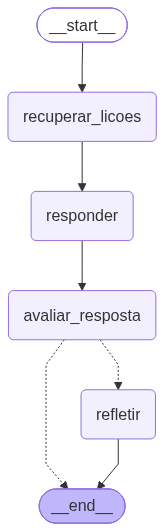

In [26]:
def decidir_apos_avaliacao(state: EstadoAgenteReflexivo) -> Literal["refletir", "__end__"]:
    """Encerra a execução depois de uma aprovação e segue para a reflexão depois de uma reprovação."""
    if state["aprovada"]:
        return END

    return "refletir"


builder = StateGraph(EstadoAgenteReflexivo, context_schema=ContextoAluno)

builder.add_node("recuperar_licoes", recuperar_licoes)
builder.add_node("responder", responder)
builder.add_node("avaliar_resposta", avaliar_resposta)
builder.add_node("refletir", refletir)

builder.add_edge(START, "recuperar_licoes")
builder.add_edge("recuperar_licoes", "responder")
builder.add_edge("responder", "avaliar_resposta")
builder.add_conditional_edges("avaliar_resposta", decidir_apos_avaliacao)
builder.add_edge("refletir", END)

agente_reflexivo = builder.compile(store=store)

display_graph(agente_reflexivo)

---

# 6. Lições acumuladas entre execuções

Renan faz quatro perguntas, cada uma em um `invoke` separado. O grafo não tem checkpointer e as execuções não compartilham estado; o store é o único meio pelo qual uma execução afeta a seguinte. Cada critério exige um ponto de conteúdo e o módulo do curso em que o tema é tratado, informação que a instrução do tutor não traz. As perguntas 1 e 2 tratam do mesmo tema, assim como as perguntas 3 e 4.

| Pergunta | Tema | Conteúdo exigido pelo critério | Módulo |
|---|---|---|---|
| 1 | separação das conversas | a separação vem do `thread_id` da configuração | `A6` |
| 2 | retomada de uma conversa | o checkpointer carrega o último checkpoint do `thread_id` | `A6` |
| 3 | reducer | função que combina o valor atual de um campo com a atualização do nó | `A4` |
| 4 | `add_messages` | as mensagens novas são acrescentadas ao fim da lista | `A4` |

A função `perguntar` passa a pergunta e o critério no estado de entrada e o nome do aluno no contexto. Ela imprime as lições recebidas pelo nó `responder`, com a similaridade de cada uma, o veredito do avaliador e a resposta.

In [27]:
perguntas_renan = [
    ("Como o checkpointer separa as conversas de alunos diferentes?",
     "A resposta atribui a separação das conversas ao thread_id passado na configuração "
     "da execução e indica que o tema é tratado no módulo A6 do curso."),
    ("Como o checkpointer encontra as conversas de um aluno que volta no dia seguinte?",
     "A resposta diz que o checkpointer carrega o último checkpoint gravado sob o thread_id "
     "passado na configuração da execução e indica que o tema é tratado no módulo A6 do curso."),
    ("O que é um reducer em LangGraph?",
     "A resposta define o reducer como a função que combina o valor atual de um campo do estado "
     "com a atualização devolvida por um nó e indica que o tema é tratado no módulo A4 do curso."),
    ("Como o reducer add_messages acumula as mensagens do estado?",
     "A resposta diz que add_messages acrescenta as mensagens novas ao fim da lista do estado "
     "e indica que o tema é tratado no módulo A4 do curso."),
]


def perguntar(grafo: CompiledStateGraph, aluno: str, pergunta: str, criterio: str) -> dict:
    """Executa o agente para uma pergunta e imprime lições, veredito e resposta."""
    resultado = grafo.invoke(
        {"messages": [HumanMessage(content=pergunta)], "criterio": criterio},
        context=ContextoAluno(aluno=aluno),
    )

    print("Pergunta:", pergunta)
    for similaridade, licao in resultado["licoes_relevantes"]:
        print(f"  lição [{similaridade:.2f}] {licao}")
    print("Aprovada:", resultado["aprovada"], "|", resultado["feedback"])
    print("Resposta:", resultado["messages"][-1].text)
    print("-" * 60)

    return resultado


for pergunta, criterio in perguntas_renan:
    perguntar(agente_reflexivo, "Renan", pergunta, criterio)

Pergunta: Como o checkpointer separa as conversas de alunos diferentes?
Aprovada: False | A resposta não menciona que a separação das conversas ocorre pelo thread_id passado na configuração da execução e não indica que o tema está tratado no módulo A6 do curso.
Resposta: O checkpointer cria um identificador único (por exemplo, um session ou user ID) para cada aluno e associa todas as mensagens a esse ID. Esse metadado é armazenado junto ao estado da conversa, de modo que ao salvar ou restaurar o checkpoint o sistema recupera apenas o histórico correspondente ao mesmo identificador. Assim, conversas de diferentes alunos permanecem isoladas, mesmo que estejam sendo processadas no mesmo servidor. Caso o usuário não possua um ID explícito, o checkpointer pode gerar um token temporário que é mantido no cookie ou no cabeçalho da requisição.
------------------------------------------------------------


Pergunta: Como o checkpointer encontra as conversas de um aluno que volta no dia seguinte?
  lição [0.09] Ao responder sobre como o checkpointer separa as conversas de alunos diferentes, inclua que a separação ocorre pelo thread_id fornecido na configuração da execução e indique que esse assunto está tratado no módulo A6 do curso.
Aprovada: True | ok
Resposta: O checkpointer grava o estado da conversa associando‑o ao **thread_id** que foi passado na configuração da execução. Quando o aluno retorna, o mesmo thread_id é usado para buscar o snapshot salvo e restaurar o contexto exatamente de onde ele parou. Esse mecanismo permite que conversas de diferentes alunos fiquem isoladas e que o histórico seja recuperado mesmo em dias diferentes. O assunto está detalhado no **módulo A6** do curso.
------------------------------------------------------------


Pergunta: O que é um reducer em LangGraph?
  lição [0.00] Ao responder sobre como o checkpointer separa as conversas de alunos diferentes, inclua que a separação ocorre pelo thread_id fornecido na configuração da execução e indique que esse assunto está tratado no módulo A6 do curso.
Aprovada: False | Não define o reducer como combinação do valor atual do campo de estado com a atualização devolvida por um nó e indica módulo errado (B3 em vez de A4).
Resposta: Um **reducer** em LangGraph é um nó especial que recebe os resultados de vários ramos paralelos da grafo e os combina em um único output. Ele permite agregar informações (por exemplo, somar scores, concatenar textos ou aplicar uma lógica de votação) antes de prosseguir para o próximo passo da cadeia. O reducer pode ser configurado com uma função personalizada que define como os dados de cada ramo serão mesclados. Essa funcionalidade está detalhada no módulo B3 do curso.
------------------------------------------------------------


Pergunta: Como o reducer add_messages acumula as mensagens do estado?
  lição [0.14] Ao responder sobre o que é um reducer em LangGraph, explique que ele combina o valor atual de um campo de estado com a atualização devolvida por um nó, e cite que essa definição está no módulo A4.
  lição [0.00] Ao responder sobre como o checkpointer separa as conversas de alunos diferentes, inclua que a separação ocorre pelo thread_id fornecido na configuração da execução e indique que esse assunto está tratado no módulo A6 do curso.
Aprovada: True | ok
Resposta: O reducer `add_messages` recebe o campo `messages` do estado atual, que já contém uma lista de mensagens, e o combina com a lista devolvida pelo nó que acabou de ser executado, concatenando‑as em ordem cronológica. Ele cria um novo estado onde `messages` é a união das mensagens antigas e das novas, preservando todas as interações. Essa lógica de “combinar o valor atual com a atualização do nó” está descrita no módulo A4 do curso.
------------

As lições gravadas no namespace de Renan ao fim das quatro execuções:

In [28]:
for item in store.search(("licoes", "renan"), limit=100):
    print("-", item.value["licao"])

- Ao responder sobre o que é um reducer em LangGraph, explique que ele combina o valor atual de um campo de estado com a atualização devolvida por um nó, e cite que essa definição está no módulo A4.
- Ao responder sobre como o checkpointer separa as conversas de alunos diferentes, inclua que a separação ocorre pelo thread_id fornecido na configuração da execução e indique que esse assunto está tratado no módulo A6 do curso.


## 6.1 Leitura da execução

1. Pergunta 1: o namespace `("licoes", "renan")` está vazio, e `recuperar_licoes` devolve uma lista vazia. A resposta atribui a separação das conversas a um identificador do aluno ou da sessão, sem o `thread_id`, e não cita o módulo. O avaliador a reprova pelos dois pontos, e `refletir` grava uma lição com o `thread_id` da configuração e o módulo `A6`.
2. Pergunta 2: a busca devolve essa lição com similaridade acima de zero, pelas palavras `checkpointer` e `conversas`, comuns às duas. A resposta cita o `thread_id` passado na configuração e o módulo `A6`, e é aprovada. A execução termina sem passar por `refletir`.
3. Pergunta 3: a única lição do namespace tem similaridade 0,00 com a pergunta sobre reducers e chega ao prompt porque `K_LICOES` é 3. A resposta descreve o reducer como um nó que combina as saídas de ramos paralelos e cita o módulo `B3`, diferente do exigido pelo critério. O avaliador a reprova, e `refletir` grava a segunda lição, com a definição exigida pelo critério e o módulo `A4`.
4. Pergunta 4: a busca devolve as duas lições, primeiro a de reducers, pela palavra `reducer`, e depois a do checkpointer, com 0,00. A resposta descreve o `add_messages` como a combinação da lista atual com as mensagens devolvidas pelo nó, nos termos da lição, cita o módulo `A4` e é aprovada.
5. O namespace termina com duas lições, uma por reprovação.

As respostas 1 e 3 continuam impressas com o erro de conteúdo, marcadas como reprovadas. A resposta 2 cita o `thread_id`, que a resposta 1 não citava, e a resposta 4 usa a definição de reducer que a resposta 3 não tinha. A sequência de vereditos (reprovada, aprovada, reprovada, aprovada) se repetiu em cinco execuções pelo `gpt-oss:120b` e em uma pelo `gemini-3.5-flash-lite`. Pelo Gemini, as respostas 1 e 3 tinham o conteúdo exigido e foram reprovadas só pela falta do módulo, e as lições gravadas registraram apenas o módulo.

## 6.2 Discussão

- Cada `invoke` é uma execução isolada, sem `thread_id`. A lição da pergunta 1 chega à pergunta 2 pelo store, e a chave de acesso é o namespace do aluno.
- A lição é lida por semelhança de vocabulário com a pergunta. A pergunta 2 recebe a lição da pergunta 1 porque as duas contêm `checkpointer` e `conversas`; uma pergunta sobre o mesmo tema escrita sem essas palavras receberia a lição com similaridade zero ou não a receberia, conforme a seção 3.5.
- Com `K_LICOES = 3` e poucas lições no namespace, lições de similaridade 0,00 também chegam ao prompt. Na pergunta 3, a instrução recebeu a lição sobre o checkpointer, e nas execuções medidas a resposta não citou o `thread_id` nem o módulo `A6`.
- O critério do professor não entra no prompt do tutor. Ele altera as respostas futuras pela lição gravada por `refletir`.

---

# 7. Limites da memória reflexiva

**Lição gravada a partir de uma avaliação errada.** O nó `refletir` grava o que o avaliador apontou. Uma reprovação indevida produz uma lição que instrui o tutor a mudar uma resposta que estava correta, e essa lição é recuperada em perguntas futuras parecidas. O avaliador desta aula confere os pontos que o critério lista, e um erro fora deles não é apontado. O critério da pergunta 4 pede que o `add_messages` acrescente as mensagens ao fim da lista; a substituição da mensagem que tem o mesmo `id` de uma já presente, que o `add_messages` também faz, fica fora da avaliação.

**Similaridade e utilidade.** Na seção 4.4, a similaridade média dos exemplos recuperados foi próxima nas questões em que o contexto ajudou (0,545) e nas em que atrapalhou (0,519). Na questão do Mount St. Helens, os exemplos recuperados tratavam de placas tectônicas, o mesmo tema da questão, e a resposta passou da alternativa correta para outra.

**Crescimento do namespace.** O agente grava uma lição a cada reprovação e não remove nenhuma. `buscar_relevantes` lê até 100 itens por chamada e recalcula os vetores de todos eles a cada pergunta, e lições sobre o mesmo tema escritas com palavras diferentes se acumulam como registros distintos. Três estratégias limitam o crescimento:

- expiração por tempo: o `SqliteStore` aceita uma configuração `ttl` na construção, e `put` aceita um `ttl` em minutos por item;
- deduplicação: antes de gravar uma lição, procurar no namespace uma lição com similaridade acima de um limiar e não gravar a nova;
- poda por uso: registrar quantas vezes cada lição foi recuperada e remover as que não são recuperadas ou que não mudam o veredito das respostas em que aparecem.

---

# 8. Exercícios de fixação

Os exercícios rodam depois de todas as células do notebook, com `store`, `agente_reflexivo`, `amostra_arc` e as funções das seções 3 a 6 definidos. O namespace `("licoes", "renan")` contém as lições gravadas na seção 6.

## Exercício 1 — Limiar de similaridade

Redefina `buscar_relevantes` com um parâmetro `limiar: float = 0.0` que descarta os itens com similaridade abaixo dele, mesmo quando estão entre os *k* primeiros. Com `limiar=0.0` e com `limiar=0.1`, execute três buscas: a consulta da seção 3.5 no namespace de episódios, e as consultas `"O que é um reducer em LangGraph?"` e `"Como o checkpointer encontra as conversas de um aluno que volta no dia seguinte?"` no namespace `("licoes", "renan")`, com `campo_texto="licao"`. Identifique, para cada consulta, quais itens o limiar removeu e se algum deles era a lição que levou à aprovação na seção 6. O nó `recuperar_licoes` procura a função pelo nome a cada execução, então `agente_reflexivo` passa a usar a versão nova sem ser recompilado; com o padrão `0.0`, o comportamento do agente não muda.

## Exercício 2 — Similaridade e acurácia

Com `amostra_arc`, calcule a mediana de `similaridade_media` e divida as 22 questões em dois grupos: acima da mediana e igual ou abaixo dela. Para cada grupo, imprima o número de questões e a acurácia nos dois cenários, com a função `acuracia` da seção 4.2. Compare o ganho do contexto nos dois grupos.

## Exercício 3 — Deduplicação de lições

Escreva `licao_repetida(store, namespace, licao, limiar) -> bool`, que usa `buscar_relevantes` com `k=1` e devolve `True` quando a lição mais parecida já gravada tem similaridade maior que `limiar`. Teste com o texto de uma lição gravada para Renan e com a frase `"Ao explicar o store, cite o módulo A6."`, e imprima a similaridade dos dois casos. Depois redefina `refletir` para não gravar a lição quando `licao_repetida` devolver `True` com limiar `0.5`. O `StateGraph` guarda a função de cada nó no momento de `add_node`, então reconstrua o `builder` da seção 5.6 e compile um grafo novo com o mesmo `store`.

## Exercício 4 — Lições por aluno

Execute as quatro perguntas de `perguntas_renan` com `agente_reflexivo` para a aluna Ana, com a função `perguntar` e `"Ana"` no lugar de `"Renan"`. Imprima as lições dos namespaces `("licoes", "ana")` e `("licoes", "renan")` e compare o veredito da primeira pergunta de Ana com o da primeira pergunta de Renan na seção 6.

## Exercício 5 — Escopo das lições

Sem rodar código, responda: as lições da seção 6 registram o conteúdo que a resposta precisa ter e o módulo do curso em que cada tema é tratado, e ficam no namespace de Renan. Indique se esse conteúdo pertence ao aluno ou ao tutor, e em qual namespace ele seria gravado para valer para todos os alunos. Descreva o que muda, nesse namespace compartilhado, quando o avaliador reprova indevidamente a resposta dada a um único aluno, e qual das estratégias da seção 7 limita esse efeito.

---

# 9. Resumo da aula

O notebook partiu de um store lido por listagem e acrescentou as duas operações da memória reflexiva: a recuperação dos registros mais parecidos com a pergunta e a gravação de uma lição depois de uma resposta reprovada. A seção 4 mediu a recuperação em dados publicados, e as seções 5 e 6 montaram o ciclo completo em um grafo sem checkpointer, em que o store liga uma execução à seguinte.

| Conceito | Ideia principal |
|---|---|
| Listagem do namespace | `search` sem `query` devolve os itens pela data de atualização, até `limit`, 10 por padrão, sem relação com a pergunta |
| TF-IDF | vetor com uma posição por palavra; peso maior para palavras presentes em poucos textos |
| Similaridade de cosseno | cosseno do ângulo entre dois vetores; 0 quando os textos não têm palavra em comum |
| Recuperação *top-k* | ordena os itens pela similaridade com a consulta e devolve os *k* primeiros, inclusive os de nota zero |
| Efeito líquido | na amostra do ARC, 8 questões melhoraram e 5 pioraram com o contexto |
| Avaliação por critério | o avaliador recebe o critério que o tutor não recebe e devolve um veredito `bool` |
| Reflexão | depois da reprovação, o modelo escreve uma lição que é gravada no namespace do aluno |
| Limites | lições de avaliações erradas, recuperação por vocabulário e crescimento do namespace |

## 9.1 Checklist de compreensão

Questões de verificação:

1. Em que ordem `store.search(namespace)` devolve os itens, e o que acontece com o décimo primeiro episódio de um aluno?
2. Qual é a diferença entre a recuperação seletiva e a reflexão, e qual das duas grava no store?
3. Por que a função `tokenizar` remove palavras como `que` e `em` antes de calcular os vetores?
4. Por que a consulta da seção 3.5 devolve três itens com similaridade 0,00, e o que mudaria com embeddings de um modelo de linguagem?
5. Na amostra do ARC, por que a acurácia agregada não basta para avaliar o efeito da recuperação?
6. Por que o critério do professor entra no estado mas não no prompt do nó `responder`?
7. Por que a instrução de reflexão pede que a lição cite o tema da pergunta?
8. Qual caminho leva a lição da primeira pergunta de Renan até a resposta da segunda, se o grafo não tem checkpointer?

## 9.2 Próximos passos

- embeddings de um modelo de linguagem no lugar da TF-IDF, com o `index` do store e o parâmetro `query` de `search`;
- expiração de itens com a configuração `ttl` do store;
- avaliação com sinal externo ao modelo, como testes automáticos ou gabarito, no lugar do avaliador por LLM;
- memória compartilhada entre alunos, com namespaces do tutor separados dos namespaces de cada aluno;
- medição do efeito líquido das lições em um conjunto de perguntas com critério conhecido.

# 10. Referências

- LangGraph, Memory overview: https://docs.langchain.com/oss/python/concepts/memory
- LangGraph, Stores: https://docs.langchain.com/oss/python/langgraph/stores
- LangGraph, Use semantic search: https://docs.langchain.com/oss/python/langgraph/add-memory#use-semantic-search
- Shinn et al., Reflexion: Language Agents with Verbal Reinforcement Learning: https://arxiv.org/abs/2303.11366
- ARC (AI2 Reasoning Challenge): https://allenai.org/data/arc
- MOHAMED, A. H.; VILLAS, L. A.; **DOS REIS, J. C.** 2025. [Leveraging LLM Reflection to Improve Small Language Model Agents’ Capabilities.](https://link.springer.com/chapter/10.1007/978-3-032-15632-7_24) In the Proceedings of the 1st International Conference on Agentic and Generative Techniques in Intelligent Computational Systems (AGENTICS). Part of the 17th International Joint Conference on Computational Intelligence (IJCCI’25). Marbella, Spain.